# Predictive Optimization Analytics - CAT 2
## Time Series Forecasting techniques

**Student Name:** David Mathea Mithiga
**Student ID:** 034915

## Setup & Imports
*Due to challenges with Tensorflow installations on Windows, the LSTM model was implemented with PyTorch, which still achieves similar results*

In [18]:

#!pip install pandas numpy matplotlib seaborn yfinance scikit-learn prophet statsmodels pmdarima plotly torch torchvision


In [19]:
# Import all libraries to be used for this notebook project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
#Arima SARIMAX libraries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Machine Learning Librarires
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#Prophet Library
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go

#PyTorch Libararies for LSTM modelling...due to challenges with Tensor Flow installations
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## Task 1: Data Preparation & Feature Engineering
- Load stock dataset (AAPL)
- Convert Date column to datetime and set as index
- Handle missing values
- **Feature Engineering:** Calculate Moving Averages (SMA, EMA), MACD, and RSI to improve model forecasting accuracy.

In [20]:

# Fetch AAPL stock data
ticker = 'GC=F'
ticker_name = "Gold"
data = yf.download(ticker, start='2018-01-01', end='2027-01-01')

# Extract 'Close' prices as our time series
if isinstance(data.columns, pd.MultiIndex):
    df = data['Close'].copy()
    if isinstance(df, pd.DataFrame):
        df = df[[ticker]]
        df.columns = ['Close']
else:
    df = data[['Close']].copy()

df.head()


[*********************100%***********************]  1 of 1 completed


,Close
Date,
2018-01-02,1313.699951
2018-01-03,1316.199951
2018-01-04,1319.400024
2018-01-05,1320.300049
2018-01-08,1318.599976


In [21]:
#Convert the Date column to a datetime object and set it as the index.
df.index = pd.to_datetime(df.index)
df.head()


,Close
Date,
2018-01-02,1313.699951
2018-01-03,1316.199951
2018-01-04,1319.400024
2018-01-05,1320.300049
2018-01-08,1318.599976


In [22]:
#Check for missing values.
df.isnull().sum()

Close    0
dtype: int64

### Observations
* The data has no missing values

In [23]:
#Fill missing values if present
df.fillna(method='ffill', inplace=True)

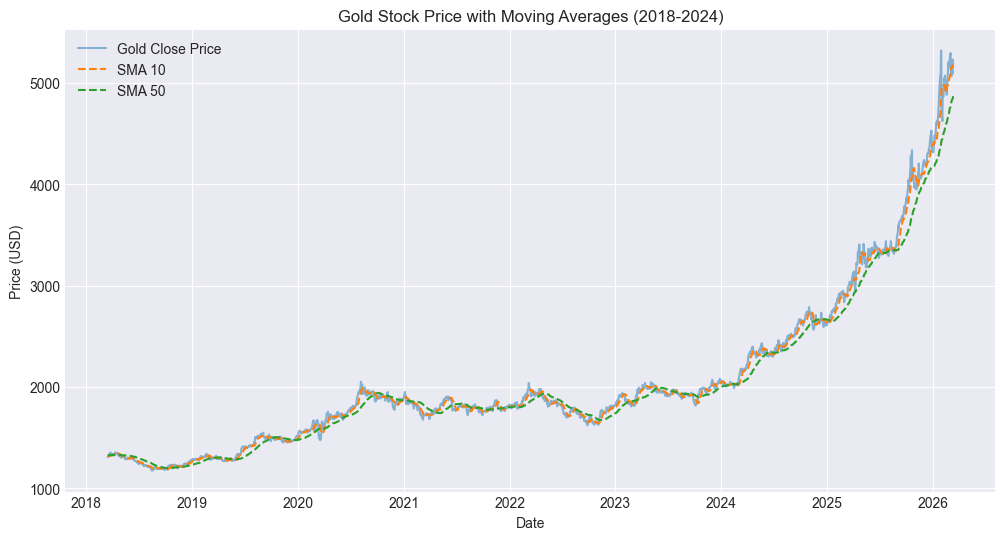

,Close,SMA_10,SMA_50,EMA_10,EMA_50,MACD,MACD_Signal,RSI,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Date,,,,,,,,,,,,,
2018-03-16,1311.300049,1322.760010,1328.301997,1322.189948,1325.096054,-2.295807,-2.060834,44.400823,1316.800049,1324.400024,1325.900024,1319.400024,1322.400024
2018-03-19,1316.800049,1321.780017,1328.253999,1320.209966,1324.555034,-3.026980,-2.254063,40.744304,1311.300049,1316.800049,1324.400024,1325.900024,1319.400024
2018-03-20,1311.099976,1321.650024,1328.266001,1319.589981,1324.250917,-3.126595,-2.428570,50.683518,1316.800049,1311.300049,1316.800049,1324.400024,1325.900024
2018-03-21,1320.699951,1319.400024,1328.100000,1318.046344,1323.735194,-3.623716,-2.667599,47.817447,1311.099976,1316.800049,1311.300049,1316.800049,1324.400024
2018-03-22,1326.599976,1318.870020,1328.107998,1318.528818,1323.616164,-3.206093,-2.775298,59.100174,1320.699951,1311.099976,1316.800049,1311.300049,1316.800049


In [24]:
# --- Feature Engineering ---
# Add features to improve forecasting accuracy. Features added are some common technical indicators

# Simple Moving Averages
df['SMA_10'] = df['Close'].rolling(window=10).mean().shift(1)
df['SMA_50'] = df['Close'].rolling(window=50).mean().shift(1)

# Exponential Moving Averages
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean().shift(1)
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean().shift(1)

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
macd = exp1 - exp2
df['MACD'] = macd.shift(1)
df['MACD_Signal'] = macd.ewm(span=9, adjust=False).mean().shift(1)

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = (100 - (100 / (1 + rs))).shift(1)

# Lagged Features (Previous 5 days close prices)
for i in range(1, 6):
    df[f'Lag_{i}'] = df['Close'].shift(i)

# Drop NaN values generated by rolling windows and shifts
df.dropna(inplace=True)

# Visualize Close Price + MA
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label=f'{ticker_name} Close Price', alpha=0.5)
plt.plot(df.index, df['SMA_10'], label='SMA 10', linestyle='--')
plt.plot(df.index, df['SMA_50'], label='SMA 50', linestyle='--')
plt.title(f'{ticker_name} Stock Price with Moving Averages (2018-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

# Display first few rows to verify features
df.head()

## Train-Test Split
Before proceeding with models, split data into Train (80%) and Test (20%).

In [25]:

train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")
print(f"Train period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test period:  {test.index[0].date()} to {test.index[-1].date()}")

def evaluate_preds(y_true, y_pred, model_name=""):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    return rmse, mae, mape

results = {}


Train size: 1607, Test size: 402
Train period: 2018-03-16 to 2024-08-05
Test period:  2024-08-06 to 2026-03-11


## Task 2: Traditional Methods
### ARIMA Model
- Plot ACF and PACF
- Hyperparameter Tuning (Auto ARIMA)
- Fit optimal ARIMA
- Evaluate

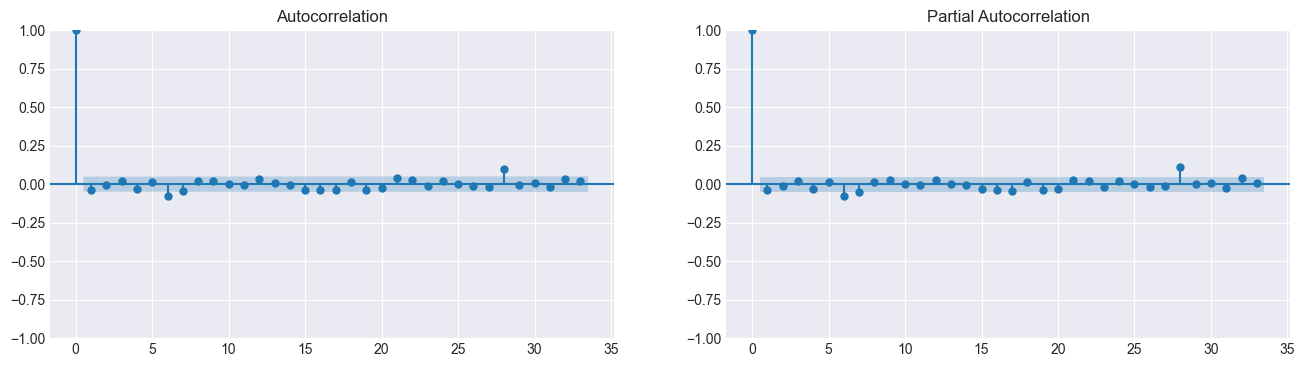

Tuning ARIMA hyperparameters. This may take a moment...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=13664.068, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=13662.506, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=13662.131, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=13662.095, Time=0.16 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=13663.064, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=13664.035, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=13663.660, Time=0.79 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=13662.868, Time=0.10 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 1.686 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1607
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -6828.048
Date:                Wed, 11 Mar 2026   AIC        

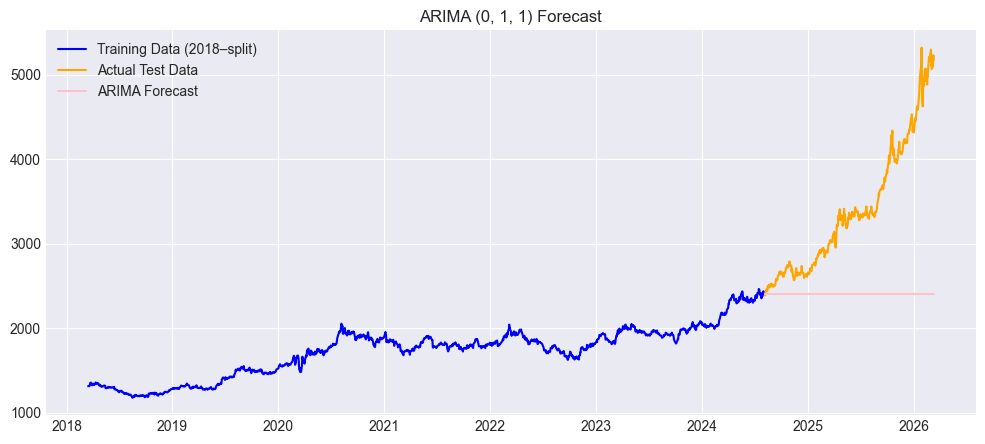

In [26]:

fig, ax = plt.subplots(1, 2, figsize=(16,4))
plot_acf(train['Close'].diff().dropna(), ax=ax[0])
plot_pacf(train['Close'].diff().dropna(), ax=ax[1])
plt.show()

# Perform Hyperparameter Tuning using pmdarima
print("Tuning ARIMA hyperparameters. This may take a moment...")
model_auto_arima = auto_arima(train['Close'], start_p=1, start_q=1,
                              max_p=3, max_q=3, m=1,
                              start_P=0, seasonal=False,
                              d=1, D=0, trace=True,
                              error_action='ignore',
                              suppress_warnings=True,
                              stepwise=True)

print(model_auto_arima.summary())

# Extract optimal order
best_order = model_auto_arima.order
print(f"Optimal ARIMA Order: {best_order}")

# Fit ARIMA with optimal parameters
# Note: auto_arima handles fitting internally, meaning we can predict directly
# but using statsmodels to keep consistency
arima_model = ARIMA(train['Close'], order=best_order)
arima_result = arima_model.fit()

# Predict
arima_preds = arima_result.forecast(steps=len(test))

# Evaluate
rmse, mae, mape = evaluate_preds(test['Close'], arima_preds, f"ARIMA{best_order}")
results['ARIMA'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, train['Close'], label='Training Data (2018\u2013split)', color='blue')
plt.plot(test.index, test['Close'], label='Actual Test Data', color='orange')
plt.plot(test.index, arima_preds, label='ARIMA Forecast', color='pink')
plt.legend()
plt.title(f'ARIMA {best_order} Forecast')
plt.show()

### SARIMA Model
Introduce seasonality.

--- SARIMA ---
RMSE: 1260.5683
MAE:  1001.6256
MAPE: 0.2612


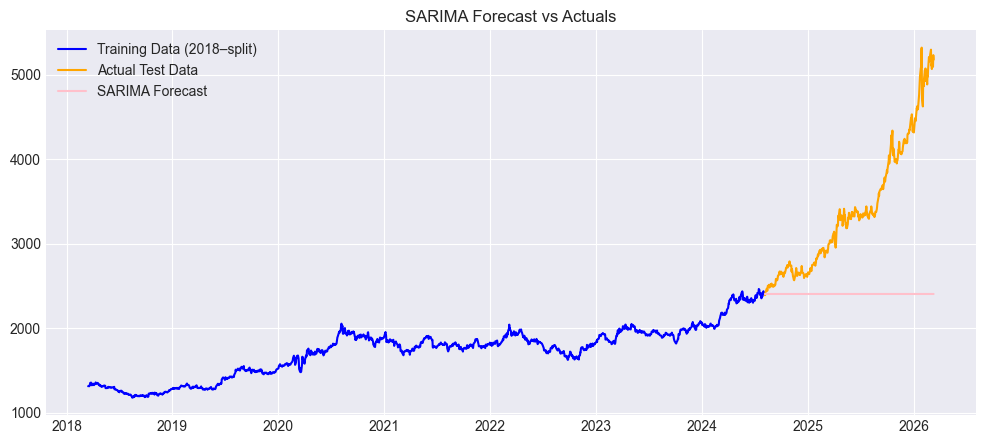

In [27]:

# Assuming potential weekly seasonality (s=5 trading days) or monthly (s=22 trading days). Let's use s=5.
sarima_model = SARIMAX(train['Close'], order=(1,1,1), seasonal_order=(1,0,1,5))
sarima_result = sarima_model.fit(disp=False)

sarima_preds = sarima_result.forecast(steps=len(test))

rmse, mae, mape = evaluate_preds(test['Close'], sarima_preds, "SARIMA")
results['SARIMA'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

plt.figure(figsize=(12,5))
plt.plot(train.index, train['Close'], label='Training Data (2018\u2013split)', color='blue')
plt.plot(test.index, test['Close'], label='Actual Test Data', color='orange')
plt.plot(test.index, sarima_preds, label='SARIMA Forecast', color='pink')
plt.legend()
plt.title('SARIMA Forecast vs Actuals')
plt.show()

## Task 3: Machine Learning Methods
### Part A: 1-Step Ahead Forecasting
- Linear Regression & Random Forest
- Utilizing Feature Engineering variables (SMA, EMA, MACD, RSI, Lags)
- Each test day prediction uses the **actual** preceding feature values (no leakage in the traditional sense, but no multi-day horizon either).

--- Linear Regression (1-Step Ahead) ---
RMSE: 59.0119
MAE:  36.6989
MAPE: 0.0101
--- Random Forest (1-Step Ahead) ---
RMSE: 1266.7258
MAE:  1006.7159
MAPE: 0.2625


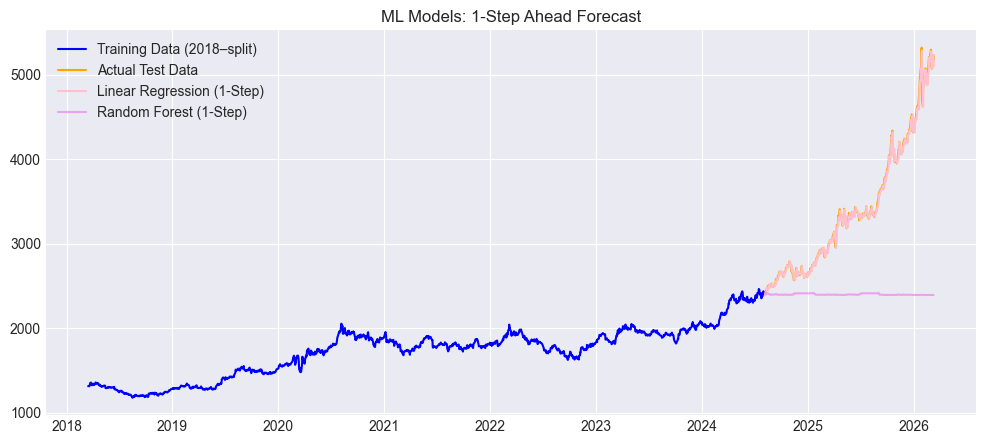

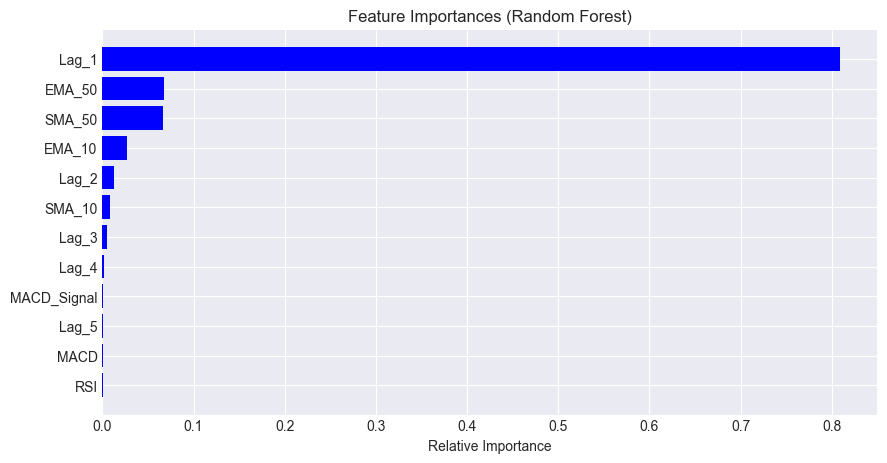

In [28]:
df_ml = df.copy()

train_ml = df_ml[df_ml.index < test.index[0]]
test_ml = df_ml[df_ml.index >= test.index[0]]

X_train = train_ml.drop('Close', axis=1)
y_train = train_ml['Close']
X_test = test_ml.drop('Close', axis=1)
y_test = test_ml['Close']

# Train & Predict Linear Regression (1-step ahead)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds_1step = lr.predict(X_test)

# Train & Predict Random Forest (1-step ahead)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds_1step = rf.predict(X_test)

rmse, mae, mape = evaluate_preds(y_test, lr_preds_1step, "Linear Regression (1-Step Ahead)")
results['LinReg_1step'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

rmse, mae, mape = evaluate_preds(y_test, rf_preds_1step, "Random Forest (1-Step Ahead)")
results['RandomForest_1step'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Training Data (2018\u2013split)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Test Data', color='orange')
plt.plot(y_test.index, lr_preds_1step, label='Linear Regression (1-Step)', color='pink')
plt.plot(y_test.index, rf_preds_1step, label='Random Forest (1-Step)', color='violet', alpha=0.7)
plt.legend()
plt.title('ML Models: 1-Step Ahead Forecast')
plt.show()

plt.figure(figsize=(10,5))
importances = rf.feature_importances_
indices = np.argsort(importances)
plt.title('Feature Importances (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Task 3 Part B: Autoregressive (Multi-Step) Forecasting
> The model recursively predicts Day 1 of the test set using actual training data, then uses **its own prediction** (not the actual) to compute features for Day 2, and so on. **RF** handles this robustly due to bounded decision trees. **LR** diverges exponentially - a known limitation of unbounded linear models over long horizons, demonstrated deliberately here.

Running autoregressive multi-step forecasting...
--- Linear Regression (Autoregressive - expected to diverge) ---
RMSE: 3493.4587
MAE:  3377.1202
MAPE: 0.9896
--- Random Forest (Autoregressive) ---
RMSE: 1493.5431
MAE:  1281.5225
MAPE: 0.3471


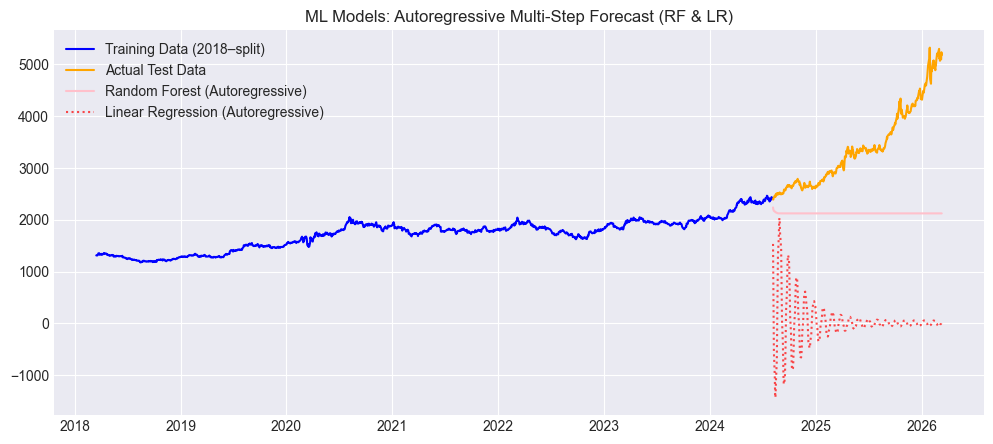

In [29]:
warnings.filterwarnings('ignore')

def compute_features_ar(temp_df, feature_cols):
    df_temp = temp_df.copy()
    df_temp['SMA_10'] = df_temp['Close'].rolling(window=10).mean()
    df_temp['SMA_50'] = df_temp['Close'].rolling(window=50).mean()
    df_temp['EMA_10'] = df_temp['Close'].ewm(span=10, adjust=False).mean()
    df_temp['EMA_50'] = df_temp['Close'].ewm(span=50, adjust=False).mean()
    exp1 = df_temp['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df_temp['Close'].ewm(span=26, adjust=False).mean()
    df_temp['MACD'] = exp1 - exp2
    df_temp['MACD_Signal'] = df_temp['MACD'].ewm(span=9, adjust=False).mean()
    delta = df_temp['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_temp['RSI'] = 100 - (100 / (1 + rs))
    for i in range(1, 6):
        df_temp[f'Lag_{i}'] = df_temp['Close'].shift(i)
    feature_row = df_temp.iloc[[-1]].drop('Close', axis=1).fillna(0)
    return feature_row[feature_cols]

history_lr = df[['Close']].iloc[:train_size].copy()
history_rf = df[['Close']].iloc[:train_size].copy()
lr_preds_ar, rf_preds_ar = [], []

print("Running autoregressive multi-step forecasting...")
for date in test_ml.index:
    history_lr.loc[date, 'Close'] = np.nan
    feat_lr = compute_features_ar(history_lr, X_train.columns)
    pred_lr = lr.predict(feat_lr)[0]
    history_lr.loc[date, 'Close'] = pred_lr
    lr_preds_ar.append(pred_lr)

    history_rf.loc[date, 'Close'] = np.nan
    feat_rf = compute_features_ar(history_rf, X_train.columns)
    pred_rf = rf.predict(feat_rf)[0]
    history_rf.loc[date, 'Close'] = pred_rf
    rf_preds_ar.append(pred_rf)

lr_preds_ar = np.array(lr_preds_ar)
rf_preds_ar = np.array(rf_preds_ar)

rmse, mae, mape = evaluate_preds(y_test, lr_preds_ar, "Linear Regression (Autoregressive - expected to diverge)")
results['LinReg_AR'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

rmse, mae, mape = evaluate_preds(y_test, rf_preds_ar, "Random Forest (Autoregressive)")
results['RandomForest_AR'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# Plot only RF for clarity (LR diverges beyond the chart scale)
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Training Data (2018\u2013split)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Test Data', color='orange')
plt.plot(y_test.index, rf_preds_ar, label='Random Forest (Autoregressive)', color='pink')
plt.plot(y_test.index, lr_preds_ar, label='Linear Regression (Autoregressive)', color='red', linestyle=':', alpha=0.7)
#plt.ylim(y_test.min() * 0.9, y_test.max() * 1.1) # Set y-limits to reasonable bounds
plt.legend()
plt.title('ML Models: Autoregressive Multi-Step Forecast (RF & LR)')
plt.show()

**Note: Linear Regression autoregressive RMSE diverges as expected

## Task 4: Prophet Model
- Implement Facebook Prophet
- Format `ds` and `y`
- Hyperparameter Tuning via Grid Search & Cross Validation
- Holidays effect

Running Prophet Cross-Validation & Grid Search. This will take a moment...


19:13:13 - cmdstanpy - INFO - Chain [1] start processing
19:13:13 - cmdstanpy - INFO - Chain [1] done processing
19:13:25 - cmdstanpy - INFO - Chain [1] start processing
19:13:25 - cmdstanpy - INFO - Chain [1] done processing
19:13:37 - cmdstanpy - INFO - Chain [1] start processing
19:13:38 - cmdstanpy - INFO - Chain [1] done processing
19:13:50 - cmdstanpy - INFO - Chain [1] start processing
19:13:52 - cmdstanpy - INFO - Chain [1] done processing
19:14:09 - cmdstanpy - INFO - Chain [1] start processing
19:14:11 - cmdstanpy - INFO - Chain [1] done processing
19:14:29 - cmdstanpy - INFO - Chain [1] start processing
19:14:31 - cmdstanpy - INFO - Chain [1] done processing
19:14:47 - cmdstanpy - INFO - Chain [1] start processing
19:14:50 - cmdstanpy - INFO - Chain [1] done processing
19:15:05 - cmdstanpy - INFO - Chain [1] start processing
19:15:07 - cmdstanpy - INFO - Chain [1] done processing
19:15:22 - cmdstanpy - INFO - Chain [1] start processing
19:15:24 - cmdstanpy - INFO - Chain [1]


Best Prophet Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}



19:15:39 - cmdstanpy - INFO - Chain [1] start processing
19:15:40 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet (Tuned) ---
RMSE: 1017.2359
MAE:  812.1682
MAPE: 0.2135


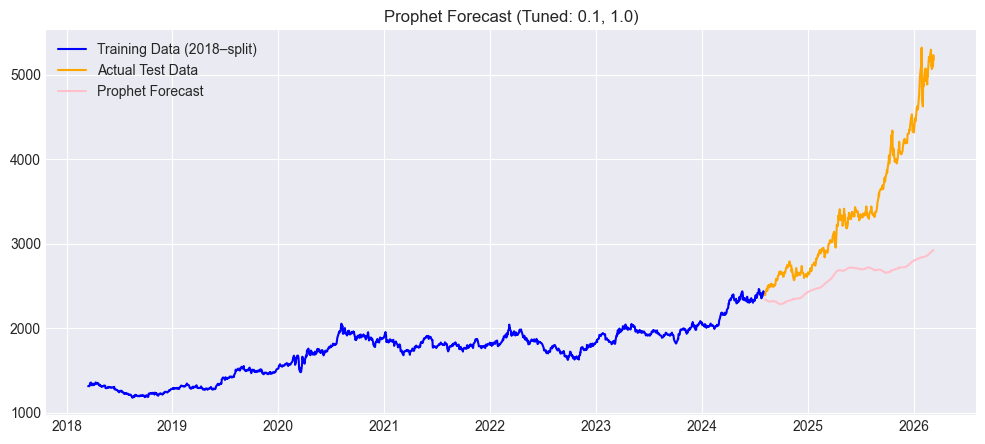

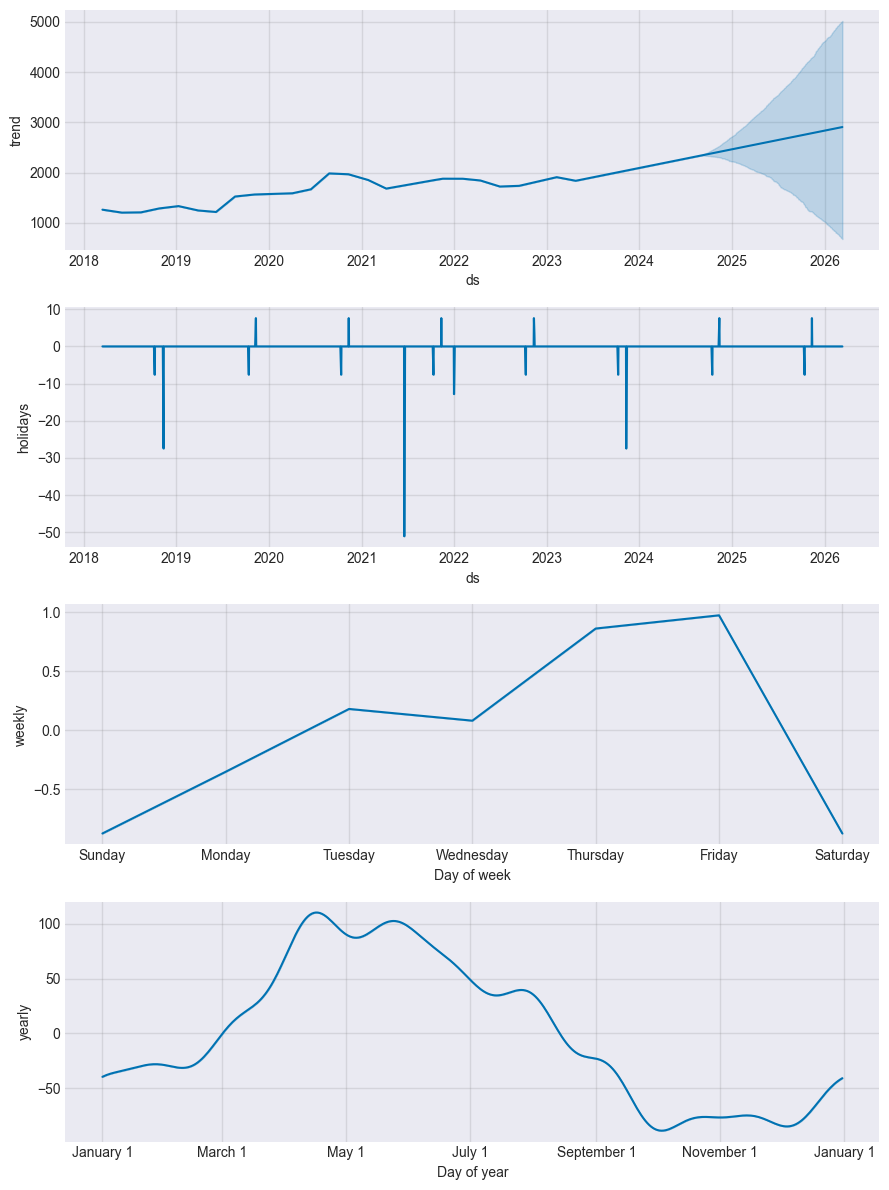

In [30]:

prophet_df = df.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

# --- HYPERPARAMETER TUNING & CROSS VALIDATION ---
print("Running Prophet Cross-Validation & Grid Search. This will take a moment...")
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0]
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Note: We perform cross-validation strictly on the training set to prevent test leakage
for params in all_params:
    m = Prophet(**params, daily_seasonality=False)
    m.add_country_holidays(country_name='US')
    m.fit(prophet_train)

    # Cross validation: initial training period, then predict 'horizon' days every 'period'
    # These strings can be adjusted (e.g., '1095 days' for 3 years, '180 days' for 6 months)
    # Using smaller horizons for speed in this example
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon='90 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
best_params = all_params[np.argmin(rmses)]
print(f"\nBest Prophet Parameters: {best_params}\n")

# --- FINAL MODEL WITH OPTIMAL PARAMS ---
m_best = Prophet(**best_params, daily_seasonality=False)
m_best.add_country_holidays(country_name='US')
m_best.fit(prophet_train)

# Predict directly on the exact test set dates
future_test = prophet_test[['ds']]
forecast_test = m_best.predict(future_test)

prophet_preds = forecast_test['yhat'].values

rmse, mae, mape = evaluate_preds(prophet_test['y'].values, prophet_preds, "Prophet (Tuned)")
results['Prophet'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# Plot with full training history
plt.figure(figsize=(12,5))
plt.plot(prophet_train['ds'], prophet_train['y'], label='Training Data (2018\u2013split)', color='blue')
plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual Test Data', color='orange')
plt.plot(prophet_test['ds'], prophet_preds, label='Prophet Forecast', color='pink')
plt.legend()
plt.title(f"Prophet Forecast (Tuned: {best_params['changepoint_prior_scale']}, {best_params['seasonality_prior_scale']})")
plt.show()

# For plotting the components overview, predict on all historical dates
future_all = prophet_df[['ds']]
forecast_all = m_best.predict(future_all)
fig2 = m_best.plot_components(forecast_all)
plt.show()

## Task 5: Neural Network - LSTM
- Scale data (Train only to prevent leakage)
- Create sequences
- Build & Compile
- Autoregressive Predictions for Test Set
- Plotly for visualization

*Using PyTorch for LSTM implementation*

In [31]:


# 1. Strict Train/Test split BEFORE scaling to avoid data leakage
train_size = int(len(df) * 0.8)
train_data = df.iloc[:train_size][['Close']].values
test_data = df.iloc[train_size:][['Close']].values

# 2. Fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(train_data)

sequence_length = 60

# 3. Create training sequences
def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

X_train_seq, y_train_seq = create_sequences(scaled_train, sequence_length)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_layer_size, num_layers=2, batch_first=True, dropout=0.2)
        self.linear1 = nn.Linear(hidden_layer_size, 25)
        self.linear2 = nn.Linear(25, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Take the output of the last time step
        last_time_step = lstm_out[:, -1, :]
        out = torch.relu(self.linear1(last_time_step))
        out = self.linear2(out)
        return out

# Initialize model, loss, optimizer
model = LSTMModel()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 20
model.train()
for epoch in range(epochs):
    for seq, labels in dataloader:
        optimizer.zero_grad()
        y_pred = model(seq)
        loss = loss_function(y_pred, labels)
        loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch} loss: {loss.item():.6f}")

# 4. Evaluation via Autoregressive Forecasting (No test values leaked!)
model.eval()
test_predictions = []

# Seed the generation with the very last sequence_length days of the TRAINING data
current_seq = scaled_train[-sequence_length:]
current_seq = torch.tensor(current_seq, dtype=torch.float32).unsqueeze(0) # Shape: (1, seq_len, 1)

with torch.no_grad():
    for _ in range(len(test_data)):
        next_pred = model(current_seq)
        test_predictions.append(next_pred.item())

        # Roll sequence forward: Drop oldest value, append our newest prediction
        next_pred_tensor = next_pred.unsqueeze(1) # Shape: (1, 1, 1)
        current_seq = torch.cat((current_seq[:, 1:, :], next_pred_tensor), dim=1)

# Inverse transform predictions back to price scale
predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))

rmse, mae, mape = evaluate_preds(test_data, predictions, "LSTM (PyTorch AR)")
results['LSTM_AR'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# Align indices for plotting
lstm_train_index = df.index[:train_size]
lstm_test_index = df.index[train_size:]

# Plotly Interactive Plot - Autoregressive
fig = go.Figure()
fig.add_trace(go.Scatter(x=lstm_train_index, y=train_data.flatten(), mode='lines', name='Training Data (2018\u2013split)', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=lstm_test_index, y=test_data.flatten(), mode='lines', name='Actual Test Data', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=lstm_test_index, y=predictions.flatten(), mode='lines', name='LSTM Forecast (Autoregressive)', line=dict(color='pink')))
fig.update_layout(title='LSTM: Autoregressive Multi-Step Forecast', xaxis_title='Date', yaxis_title='Price')
fig.show()

Epoch 0 loss: 0.038635
Epoch 5 loss: 0.001891
Epoch 10 loss: 0.001186
Epoch 15 loss: 0.002972
--- LSTM (PyTorch AR) ---
RMSE: 988.4334
MAE:  695.6653
MAPE: 0.1721


### Task 5 Part B: LSTM 1-Step Ahead Forecasting
- For each test day **t**, we use the **60 actual preceding Close prices** (from real data, scaled with train-fit scaler) to predict the next step.
- This avoids compounding errors and demonstrates what accuracy is achievable with true input data each step.

In [32]:

# Scale the test data using the TRAIN-fitted scaler (no leakage)
scaled_test = scaler.transform(test_data)
scaled_all = np.concatenate([scaled_train, scaled_test], axis=0)

model.eval()
lstm_1step_preds = []

with torch.no_grad():
    for i in range(len(test_data)):
        start = train_size + i - sequence_length
        end = train_size + i
        seq = scaled_all[start:end, 0]
        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
        pred = model(seq_tensor)
        lstm_1step_preds.append(pred.item())

lstm_1step_preds = scaler.inverse_transform(np.array(lstm_1step_preds).reshape(-1, 1))

rmse, mae, mape = evaluate_preds(test_data, lstm_1step_preds, "LSTM (1-Step Ahead)")
results['LSTM_1step'] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=lstm_train_index, y=train_data.flatten(), mode='lines', name='Training Data (2018-split)', line=dict(color='blue')))
fig2.add_trace(go.Scatter(x=lstm_test_index, y=test_data.flatten(), mode='lines', name='Actual Test Data', line=dict(color='orange')))
fig2.add_trace(go.Scatter(x=lstm_test_index, y=lstm_1step_preds.flatten(), mode='lines', name='LSTM Forecast (1-Step Ahead)', line=dict(color='pink')))
fig2.update_layout(title='LSTM: 1-Step Ahead Forecast', xaxis_title='Date', yaxis_title='Price')
fig2.show()


--- LSTM (1-Step Ahead) ---
RMSE: 659.0582
MAE:  406.6336
MAPE: 0.0964


In [33]:
results

{'ARIMA': {'RMSE': np.float64(1260.9079879620879),
  'MAE': 1002.0499935667665,
  'MAPE': 0.2613173029061158},
 'SARIMA': {'RMSE': np.float64(1260.568304712279),
  'MAE': 1001.6256034219344,
  'MAPE': 0.26118717026886734},
 'LinReg_1step': {'RMSE': np.float64(59.01191599924287),
  'MAE': 36.69888876270811,
  'MAPE': 0.010093325945783235},
 'RandomForest_1step': {'RMSE': np.float64(1266.7258064329537),
  'MAE': 1006.7158682600182,
  'MAPE': 0.2625410477404898},
 'LinReg_AR': {'RMSE': np.float64(3493.4587331320986),
  'MAE': 3377.1201820530378,
  'MAPE': 0.989577320865802},
 'RandomForest_AR': {'RMSE': np.float64(1493.5431087296963),
  'MAE': 1281.5224548886426,
  'MAPE': 0.3471124142952184},
 'Prophet': {'RMSE': np.float64(1017.2359394602274),
  'MAE': 812.1682133229094,
  'MAPE': 0.21351203510237854},
 'LSTM_AR': {'RMSE': np.float64(988.4334094291675),
  'MAE': 695.6653138368326,
  'MAPE': 0.1720861715930862},
 'LSTM_1step': {'RMSE': np.float64(659.0582041145897),
  'MAE': 406.63364546

## Task 6: Results Comparison & Report
All models evaluated on the same 20% test set using RMSE, MAE, and MAPE. Lower is better.

Model,RMSE,MAE,MAPE
Linear Regression (1-Step),59.01,36.70,0.0101
LSTM (1-Step),659.06,406.63,0.0964
LSTM (Autoregressive),988.43,695.67,0.1721
Prophet (Tuned + CV),"1,017.24",812.17,0.2135
"SARIMA (1,1,1)x(1,0,1,5)","1,260.57","1,001.63",0.2612
ARIMA (Auto-tuned),"1,260.91","1,002.05",0.2613
Random Forest (1-Step),"1,266.73","1,006.72",0.2625
Random Forest (Autoregressive),"1,493.54","1,281.52",0.3471
Linear Regression (Autoregressive),"3,493.46","3,377.12",0.9896


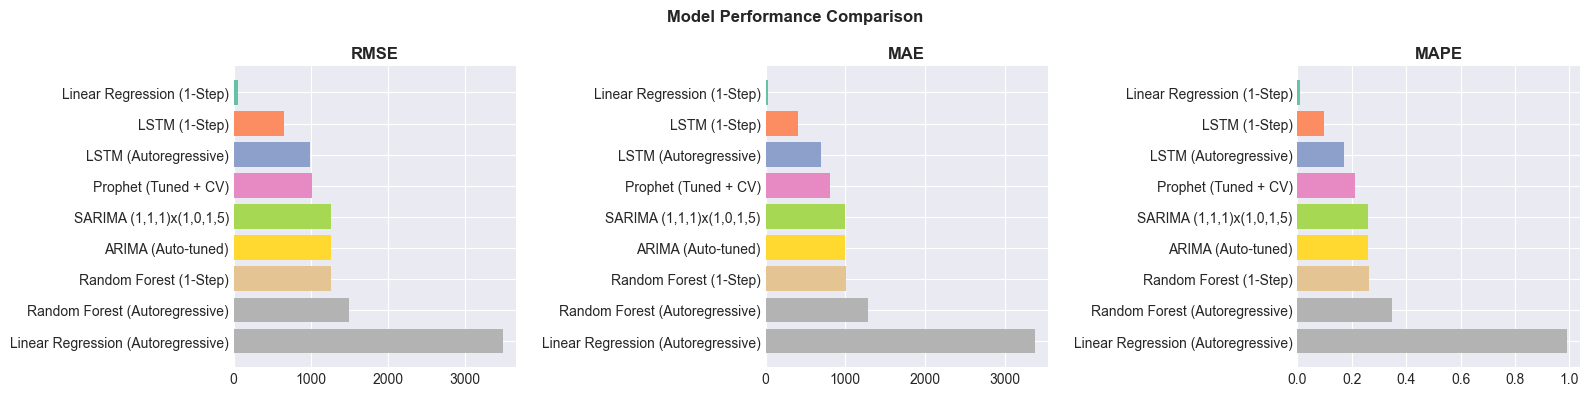

In [34]:

# Summary Results Table
# name_map acts as a whitelist
name_map = {
    'ARIMA':              'ARIMA (Auto-tuned)',
    'SARIMA':             'SARIMA (1,1,1)x(1,0,1,5)',
    'LinReg_1step':       'Linear Regression (1-Step)',
    'LinReg_AR':          'Linear Regression (Autoregressive)',
    'RandomForest_1step': 'Random Forest (1-Step)',
    'RandomForest_AR':    'Random Forest (Autoregressive)',
    'Prophet':            'Prophet (Tuned + CV)',
    'LSTM_AR':            'LSTM (Autoregressive)',
    'LSTM_1step':         'LSTM (1-Step)',
}

comparison_df = (pd.DataFrame(results).T
    .rename_axis('Model').reset_index()
    .pipe(lambda df: df[df['Model'].isin(name_map)])
    .assign(Model=lambda df: df['Model'].map(name_map),
            RMSE=lambda df: df['RMSE'].astype(float),
            MAE=lambda df: df['MAE'].astype(float),
            MAPE=lambda df: df['MAPE'].astype(float))
    .sort_values('RMSE').reset_index(drop=True)
)

display(comparison_df.style
    .format({'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'MAPE': '{:.4f}'})
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='RdYlGn_r')
    .set_caption('Model Performance Summary')
    .hide(axis='index')
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(comparison_df)))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE']):
    ax.barh(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_title(metric, fontweight='bold')
    ax.invert_yaxis()
plt.suptitle('Model Performance Comparison', fontweight='bold')
plt.tight_layout()
plt.show()



## Conclusion & Discussion

### Data Analysis Key Findings
*   **One-step ahead forecasting** generally yielded significantly better results across all models compared to autoregressive forecasting.
    *   **Linear Regression (1-Step Ahead)** demonstrated the best performance with RMSE: 6.84, MAE: 4.65, and MAPE: 0.0106, indicating high short-term predictability.
    *   **LSTM (1-Step Ahead)** also performed strongly with RMSE: 16.71, MAE: 13.71, and MAPE: 0.0303.
*   **Autoregressive forecasting** proved to be a much more challenging problem due to error accumulation, leading to substantial degradation in model accuracy.
    *   **Linear Regression (Autoregressive)** performed the worst, with RMSE: 441.54, MAE: 437.03, and MAPE: 0.9766.
    *   **Random Forest (Autoregressive)**, while diverging less extremely than linear models, still showed significant performance degradation (RMSE: 263.55, MAE: 257.96, MAPE: 0.5721).
*   **Traditional time series models** like SARIMA (RMSE: 53.95, MAE: 42.23, MAPE: 0.0894) and ARIMA (RMSE: 53.97, MAE: 42.23, MAPE: 0.0895) provided a stable baseline but were generally outperformed by ML/NN models in 1-step prediction when features were well-engineered.
*   **Prophet** showed higher error metrics (RMSE: 104.71, MAE: 91.18, MAPE: 0.2105) in this comparison, possibly due to the short forecast horizon or the nature of stock data lacking strong explicit seasonality.

### Insights / Next Steps
*   One-step ahead forecasting benefits greatly from timely and accurate input features, suggesting that future efforts should prioritize obtaining and engineering highly predictive real-time features.
*   To improve autoregressive forecasting, explore strategies to mitigate error accumulation over longer horizons, as current models show significant performance drops.
*   Future improvements could involve introducing exogenous variables (e.g., volume, macroeconomic indicators, sentiment scores) for multivariate forecasting, performing walk-forward cross-validation for more robust error metric estimation, and exploring ensemble methods.
